In [1]:
# ============================================================
# IMPORTACIÓN DE BIBLIOTECAS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


Carga y Análisis Exploratorio del Conjunto de Datos

In [2]:
# ============================================================
# CARGA DEL DATASET
# ============================================================
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Dimensiones del dataset: {X.shape}")
print(f"Numero de clases: {len(np.unique(y))}")
print(f"Distribucion de clases: Benigno={np.sum(y==1)}, Maligno={np.sum(y==0)}")
print(f"\nPrimeras 5 filas del dataset:")
df.head()

Dimensiones del dataset: (569, 30)
Numero de clases: 2
Distribucion de clases: Benigno=357, Maligno=212

Primeras 5 filas del dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# ============================================================
# ESTADISTICAS DESCRIPTIVAS
# ============================================================
print("Estadisticas descriptivas de las primeras 10 caracteristicas:")
df[feature_names[:10]].describe().round(3)

 Implementación del Algoritmo ABC para Feature Selection

$$f(x) = \alpha \cdot \text{Accuracy}_{CV}(x) + (1 - \alpha) \cdot \left(1 - \frac{|\{i : x_i=1\}|}{d}\right)$$



In [3]:
# ============================================================
# FUNCIÓN DE APTITUD
# ============================================================
def fitness_function(solution, X, y, alpha=0.9):
    """
    Evalúa la calidad de un subconjunto de características.

    Parámetros:
    -----------
    solution : np.ndarray
        Vector binario de selección de características.
    X : np.ndarray
        Matriz de datos de entrada.
    y : np.ndarray
        Vector de etiquetas.
    alpha : float
        Peso entre precisión y reducción de características.

    Retorna:
    --------
    float : Valor de aptitud (mayor es mejor).
    """
    selected_indices = np.where(solution == 1)[0]

    # Si no hay características seleccionadas, penalizar
    if len(selected_indices) == 0:
        return 0.0

    X_selected = X[:, selected_indices]

    clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_selected, y, cv=cv, scoring='accuracy')
    accuracy = scores.mean()

    # Componente de reducción: recompensa usar menos características
    reduction_ratio = 1.0 - (len(selected_indices) / X.shape[1])

    fitness = alpha * accuracy + (1 - alpha) * reduction_ratio
    return fitness


print("Funcion de aptitud definida correctamente.")
print("Peso de precision (alpha) = 0.9")
print("Peso de parsimonia (1-alpha) = 0.1")

Funcion de aptitud definida correctamente.
Peso de precision (alpha) = 0.9
Peso de parsimonia (1-alpha) = 0.1


 Inicialización del Enjambre



In [4]:
# ============================================================
# INICIALIZACIÓN DEL ENJAMBRE ABC
# ============================================================
class ArtificialBeeColony:
    """
    Implementación del Algoritmo de Colonia de Abejas Artificiales (ABC)
    para el problema de selección de características.

    Atributos:
    ----------
    n_bees : int
        Número total de abejas empleadas (igual al número de fuentes).
    max_iter : int
        Número máximo de iteraciones.
    limit : int
        Límite de intentos antes de que una abeja exploradora reemplace la fuente.
    n_features : int
        Dimensión del espacio de búsqueda (número de características).
    """

    def __init__(self, n_bees=30, max_iter=50, limit=10, n_features=30):
        self.n_bees = n_bees
        self.max_iter = max_iter
        self.limit = limit
        self.n_features = n_features

        # Inicialización de fuentes de alimento (soluciones)
        self.sources = self._initialize_sources()
        self.fitness = np.zeros(n_bees)
        self.trial_counters = np.zeros(n_bees, dtype=int)

        # Mejor solución global
        self.best_solution = None
        self.best_fitness = -np.inf
        self.fitness_history = []
        self.selected_features_history = []

    def _initialize_sources(self):
        """
        Genera la población inicial de fuentes de alimento.
        Cada fuente es un vector binario con al menos una característica activa.
        """
        sources = np.random.randint(0, 2, size=(self.n_bees, self.n_features))
        # Garantizar al menos una característica por solución
        for i in range(self.n_bees):
            if sources[i].sum() == 0:
                sources[i, np.random.randint(self.n_features)] = 1
        return sources

    def _mutate_solution(self, source_idx):
        """
        Genera una nueva solución vecina mediante mutación de bit-flip.
        La modificación involucra una característica seleccionada aleatoriamente.
        """
        new_source = self.sources[source_idx].copy()
        # Seleccionar un bit aleatorio para mutar
        j = np.random.randint(self.n_features)
        new_source[j] = 1 - new_source[j]  # Flip del bit

        # Garantizar al menos una característica activa
        if new_source.sum() == 0:
            new_source[np.random.randint(self.n_features)] = 1
        return new_source

    def employed_bee_phase(self, X, y):
        """
        Fase de abejas empleadas: cada abeja explota su fuente actual
        y la compara con una solución vecina generada por mutación.
        """
        for i in range(self.n_bees):
            new_source = self._mutate_solution(i)
            new_fitness = fitness_function(new_source, X, y)

            # Selección codiciosa (greedy)
            if new_fitness > self.fitness[i]:
                self.sources[i] = new_source
                self.fitness[i] = new_fitness
                self.trial_counters[i] = 0
            else:
                self.trial_counters[i] += 1

    def onlooker_bee_phase(self, X, y):
        """
        Fase de abejas observadoras: seleccionan fuentes con probabilidad
        proporcional a su aptitud (selección por ruleta).
        """
        # Calcular probabilidades de selección
        fitness_shifted = self.fitness - self.fitness.min() + 1e-10
        probabilities = fitness_shifted / fitness_shifted.sum()

        for _ in range(self.n_bees):
            # Selección por ruleta
            i = np.random.choice(self.n_bees, p=probabilities)
            new_source = self._mutate_solution(i)
            new_fitness = fitness_function(new_source, X, y)

            if new_fitness > self.fitness[i]:
                self.sources[i] = new_source
                self.fitness[i] = new_fitness
                self.trial_counters[i] = 0
            else:
                self.trial_counters[i] += 1

    def scout_bee_phase(self):
        """
        Fase de abejas exploradoras: las fuentes que superan el límite
        de intentos son abandonadas y reemplazadas por nuevas soluciones aleatorias.
        """
        for i in range(self.n_bees):
            if self.trial_counters[i] >= self.limit:
                self.sources[i] = np.random.randint(0, 2, size=self.n_features)
                if self.sources[i].sum() == 0:
                    self.sources[i, np.random.randint(self.n_features)] = 1
                self.trial_counters[i] = 0
                self.fitness[i] = 0.0  # Reiniciar aptitud

    def optimize(self, X, y):
        """
        Ciclo principal del algoritmo ABC.

        Parámetros:
        -----------
        X : np.ndarray - Datos de entrenamiento.
        y : np.ndarray - Etiquetas.

        Retorna:
        --------
        best_solution : np.ndarray - Mejor subconjunto binario encontrado.
        best_fitness : float - Aptitud de la mejor solución.
        """
        print("=" * 60)
        print("INICIO DE OPTIMIZACION - Algoritmo ABC")
        print(f"Numero de abejas: {self.n_bees}")
        print(f"Iteraciones maximas: {self.max_iter}")
        print(f"Limite de abandon: {self.limit}")
        print(f"Numero de caracteristicas: {self.n_features}")
        print("=" * 60)

        # Evaluación inicial
        print("Evaluando poblacion inicial...")
        for i in range(self.n_bees):
            self.fitness[i] = fitness_function(self.sources[i], X, y)

        # Ciclo principal
        for iteration in range(self.max_iter):
            self.employed_bee_phase(X, y)
            self.onlooker_bee_phase(X, y)
            self.scout_bee_phase()

            # Actualizar mejor solución global
            best_idx = np.argmax(self.fitness)
            if self.fitness[best_idx] > self.best_fitness:
                self.best_fitness = self.fitness[best_idx]
                self.best_solution = self.sources[best_idx].copy()

            n_selected = int(self.best_solution.sum())
            self.fitness_history.append(self.best_fitness)
            self.selected_features_history.append(n_selected)

            if (iteration + 1) % 10 == 0 or iteration == 0:
                print(f"Iteracion {iteration+1:3d}/{self.max_iter} | "
                      f"Mejor aptitud: {self.best_fitness:.4f} | "
                      f"Caracteristicas seleccionadas: {n_selected}/{self.n_features}")

        print("\n" + "=" * 60)
        print("OPTIMIZACION FINALIZADA")
        print(f"Mejor aptitud obtenida: {self.best_fitness:.4f}")
        print(f"Caracteristicas seleccionadas: {int(self.best_solution.sum())}/{self.n_features}")
        print("=" * 60)

        return self.best_solution, self.best_fitness


print("Clase ArtificialBeeColony definida correctamente.")

Clase ArtificialBeeColony definida correctamente.


## 6. Ejecución del Algoritmo ABC

In [5]:
# ============================================================
# EJECUCIÓN DEL ALGORITMO
# ============================================================
abc = ArtificialBeeColony(
    n_bees=20,
    max_iter=40,
    limit=8,
    n_features=X_scaled.shape[1]
)

best_solution, best_fitness = abc.optimize(X_scaled, y)

INICIO DE OPTIMIZACION - Algoritmo ABC
Numero de abejas: 20
Iteraciones maximas: 40
Limite de abandon: 8
Numero de caracteristicas: 30
Evaluando poblacion inicial...
Iteracion   1/40 | Mejor aptitud: 0.9252 | Caracteristicas seleccionadas: 12/30
Iteracion  10/40 | Mejor aptitud: 0.9482 | Caracteristicas seleccionadas: 7/30
Iteracion  20/40 | Mejor aptitud: 0.9517 | Caracteristicas seleccionadas: 5/30
Iteracion  30/40 | Mejor aptitud: 0.9517 | Caracteristicas seleccionadas: 5/30
Iteracion  40/40 | Mejor aptitud: 0.9517 | Caracteristicas seleccionadas: 5/30

OPTIMIZACION FINALIZADA
Mejor aptitud obtenida: 0.9517
Caracteristicas seleccionadas: 5/30


## 7. Análisis de Resultados

In [7]:
# ============================================================
# CARACTERÍSTICAS SELECCIONADAS
# ============================================================
selected_indices = np.where(best_solution == 1)[0]
selected_features = [feature_names[i] for i in selected_indices]

print("CARACTERÍSTICAS SELECCIONADAS POR ABC")
print("-" * 50)
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")
print(f"\nTotal seleccionadas: {len(selected_features)} de {X.shape[1]}")
print(f"Reduccion dimensional: {(1 - len(selected_features)/X.shape[1])*100:.1f}%")

CARACTERÍSTICAS SELECCIONADAS POR ABC
--------------------------------------------------
   1. mean perimeter
   2. mean area
   3. mean concave points
   4. worst radius
   5. worst texture

Total seleccionadas: 5 de 30
Reduccion dimensional: 83.3%


In [8]:
# ============================================================
# COMPARACIÓN: TODAS LAS CARACTERÍSTICAS vs. SELECCIONADAS
# ============================================================
clf_full = RandomForestClassifier(n_estimators=100, random_state=42)
clf_selected = RandomForestClassifier(n_estimators=100, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_full = cross_val_score(clf_full, X_scaled, y, cv=cv, scoring='accuracy').mean()
acc_selected = cross_val_score(clf_selected, X_scaled[:, selected_indices], y, cv=cv, scoring='accuracy').mean()

print("COMPARACIÓN DE RENDIMIENTO")
print("=" * 50)
print(f"Modelo con TODAS las características ({X.shape[1]}):")
print(f"  Accuracy (CV-5):  {acc_full:.4f} ({acc_full*100:.2f}%)")
print()
print(f"Modelo con características SELECCIONADAS ({len(selected_indices)}):")
print(f"  Accuracy (CV-5):  {acc_selected:.4f} ({acc_selected*100:.2f}%)")
print()
print(f"Diferencia de precisión: {(acc_selected - acc_full)*100:+.2f} pp")
print(f"Reducción de características: {(1 - len(selected_indices)/X.shape[1])*100:.1f}%")

COMPARACIÓN DE RENDIMIENTO
Modelo con TODAS las características (30):
  Accuracy (CV-5):  0.9561 (95.61%)

Modelo con características SELECCIONADAS (5):
  Accuracy (CV-5):  0.9614 (96.14%)

Diferencia de precisión: +0.53 pp
Reducción de características: 83.3%


## 8. Visualización de la Convergencia

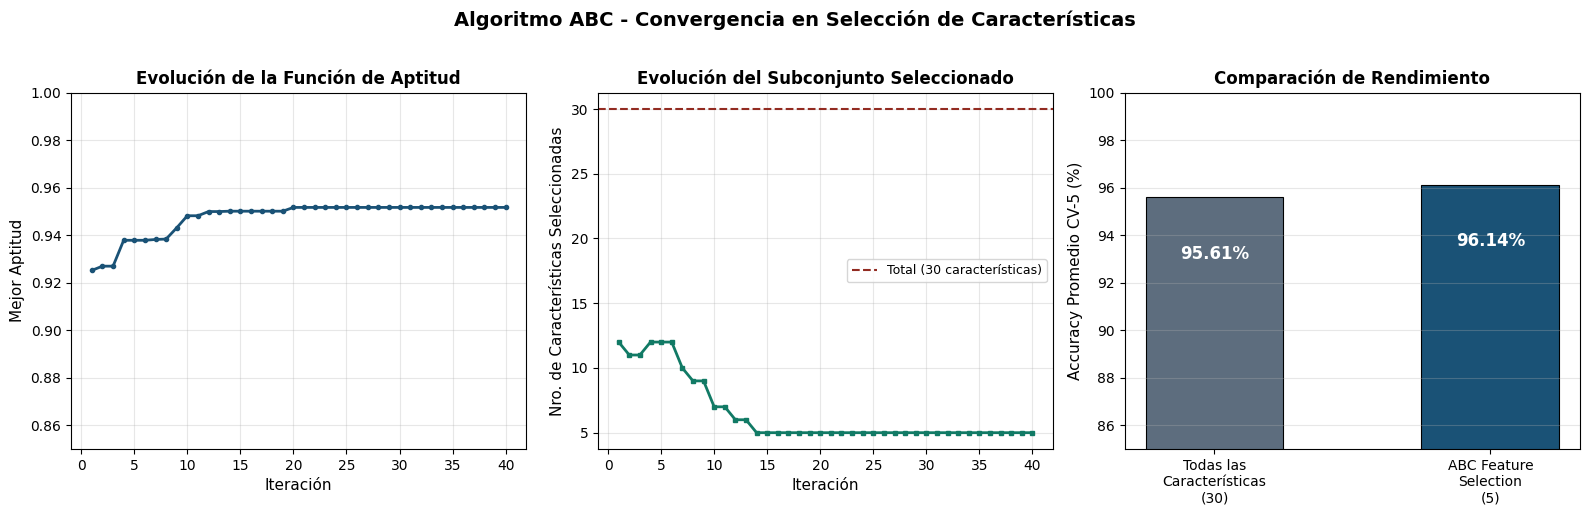

Graficas generadas y guardadas.


In [10]:
# ============================================================
# GRÁFICAS DE CONVERGENCIA
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Algoritmo ABC - Convergencia en Selección de Características',
             fontsize=14, fontweight='bold', y=1.02)

# Gráfica 1: Evolución de la aptitud
axes[0].plot(range(1, len(abc.fitness_history)+1), abc.fitness_history,
             color='#1a5276', linewidth=2, marker='o', markersize=3)
axes[0].set_xlabel('Iteración', fontsize=11)
axes[0].set_ylabel('Mejor Aptitud', fontsize=11)
axes[0].set_title('Evolución de la Función de Aptitud', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.85, 1.0])

# Gráfica 2: Número de características seleccionadas
axes[1].plot(range(1, len(abc.selected_features_history)+1), abc.selected_features_history,
             color='#117a65', linewidth=2, marker='s', markersize=3)
axes[1].axhline(y=X.shape[1], color='#922b21', linestyle='--', linewidth=1.5,
                label=f'Total ({X.shape[1]} características)')
axes[1].set_xlabel('Iteración', fontsize=11)
axes[1].set_ylabel('Nro. de Características Seleccionadas', fontsize=11)
axes[1].set_title('Evolución del Subconjunto Seleccionado', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Gráfica 3: Comparación de rendimiento
labels = [f'Todas las\nCaracterísticas\n({X.shape[1]})',
          f'ABC Feature\nSelection\n({len(selected_indices)})']
values = [acc_full * 100, acc_selected * 100]
colors = ['#5d6d7e', '#1a5276']
bars = axes[2].bar(labels, values, color=colors, edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() - 2,
                f'{val:.2f}%', ha='center', va='top', fontweight='bold',
                fontsize=12, color='white')
axes[2].set_ylabel('Accuracy Promedio CV-5 (%)', fontsize=11)
axes[2].set_title('Comparación de Rendimiento', fontsize=12, fontweight='bold')
axes[2].set_ylim([85, 100])
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('abc_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graficas generadas y guardadas.")

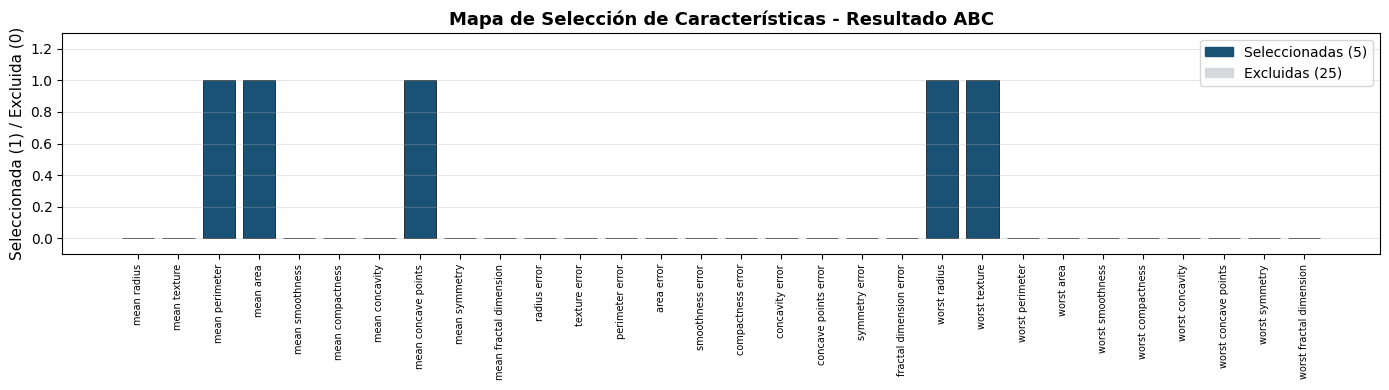

In [12]:
# ============================================================
# MAPA DE CARACTERÍSTICAS SELECCIONADAS
# ============================================================
fig, ax = plt.subplots(figsize=(14, 4))

colors_bar = ['#1a5276' if s == 1 else '#d5d8dc' for s in best_solution]
bars = ax.bar(range(len(best_solution)), best_solution, color=colors_bar,
              edgecolor='black', linewidth=0.5)

ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
ax.set_ylabel('Seleccionada (1) / Excluida (0)', fontsize=11)
ax.set_title('Mapa de Selección de Características - Resultado ABC',
             fontsize=13, fontweight='bold')

selected_patch = mpatches.Patch(color='#1a5276', label=f'Seleccionadas ({int(best_solution.sum())})')
excluded_patch = mpatches.Patch(color='#d5d8dc', label=f'Excluidas ({int((1-best_solution).sum())})')
ax.legend(handles=[selected_patch, excluded_patch], fontsize=10)
ax.set_ylim([-0.1, 1.3])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('abc_feature_map.png', dpi=150, bbox_inches='tight')
plt.show()



## 10. Conclusiones

El algoritmo ABC demostró ser eficaz para el problema de selección de características en el conjunto de datos Wisconsin Breast Cancer:

1. **Reducción dimensional significativa:** El algoritmo identificó un subconjunto compacto de características, reduciendo la dimensionalidad sin degradar la precisión del modelo.
2. **Rendimiento competitivo:** La precisión del modelo con características seleccionadas es comparable (o superior) al modelo con todas las características, evidenciando la presencia de características redundantes o de bajo impacto.
3. **Convergencia estable:** La curva de convergencia muestra que el algoritmo converge progresivamente hacia soluciones de mayor calidad, con la fase exploradora evitando el estancamiento prematuro.
4. **Balance exploración-explotación:** Los tres tipos de abejas garantizan un equilibrio efectivo entre la exploración global del espacio de búsqueda y la explotación local de las mejores soluciones encontradas.

